<a href="https://colab.research.google.com/github/ibrahim-entri/E-commerce-Sales-Analysis-using-Excel/blob/main/Python_DA_Assignment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Load taxis dataset
df = sns.load_dataset("taxis")


# Show first 5 rows
print(df.head())

               pickup             dropoff  passengers  distance  fare   tip  \
0 2019-03-23 20:21:09 2019-03-23 20:27:24           1      1.60   7.0  2.15   
1 2019-03-04 16:11:55 2019-03-04 16:19:00           1      0.79   5.0  0.00   
2 2019-03-27 17:53:01 2019-03-27 18:00:25           1      1.37   7.5  2.36   
3 2019-03-10 01:23:59 2019-03-10 01:49:51           1      7.70  27.0  6.15   
4 2019-03-30 13:27:42 2019-03-30 13:37:14           3      2.16   9.0  1.10   

   tolls  total   color      payment            pickup_zone  \
0    0.0  12.95  yellow  credit card        Lenox Hill West   
1    0.0   9.30  yellow         cash  Upper West Side South   
2    0.0  14.16  yellow  credit card          Alphabet City   
3    0.0  36.95  yellow  credit card              Hudson Sq   
4    0.0  13.40  yellow  credit card           Midtown East   

            dropoff_zone pickup_borough dropoff_borough  
0    UN/Turtle Bay South      Manhattan       Manhattan  
1  Upper West Side South      

In [5]:
# Dataset information
print(df.info())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6433 non-null   datetime64[ns]
 1   dropoff          6433 non-null   datetime64[ns]
 2   passengers       6433 non-null   int64         
 3   distance         6433 non-null   float64       
 4   fare             6433 non-null   float64       
 5   tip              6433 non-null   float64       
 6   tolls            6433 non-null   float64       
 7   total            6433 non-null   float64       
 8   color            6433 non-null   object        
 9   payment          6389 non-null   object        
 10  pickup_zone      6407 non-null   object        
 11  dropoff_zone     6388 non-null   object        
 12  pickup_borough   6407 non-null   object        
 13  dropoff_borough  6388 non-null   object        
dtypes: datetime64[ns](2), float64(5), int64(

Handling Missing Values

In [4]:
# Check missing values

print(df.isnull().sum())

pickup              0
dropoff             0
passengers          0
distance            0
fare                0
tip                 0
tolls               0
total               0
color               0
payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64


In [12]:
# Fill numerical missing values with median

num_cols = ['fare', 'tip', 'distance', 'tolls', 'total']

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

print(df[num_cols].head())

   fare   tip  distance  tolls  total
0   7.0  2.15      1.60    0.0  12.95
1   5.0  0.00      0.79    0.0   9.30
2   7.5  2.36      1.37    0.0  14.16
3  27.0  6.15      7.70    0.0  36.95
4   9.0  1.10      2.16    0.0  13.40


In [13]:
# Fill categorical missing values with mode

cat_cols = ['payment', 'pickup_borough', 'dropoff_borough']

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print(df[num_cols].head())

   fare   tip  distance  tolls  total
0   7.0  2.15      1.60    0.0  12.95
1   5.0  0.00      0.79    0.0   9.30
2   7.5  2.36      1.37    0.0  14.16
3  27.0  6.15      7.70    0.0  36.95
4   9.0  1.10      2.16    0.0  13.40


In [15]:
# Remove remaining missing rows

df.dropna(inplace=True)

# Check again


print(df.isnull().sum())

pickup             0
dropoff            0
passengers         0
distance           0
fare               0
tip                0
tolls              0
total              0
color              0
payment            0
pickup_zone        0
dropoff_zone       0
pickup_borough     0
dropoff_borough    0
dtype: int64


 Visualizations using Matplotlib/Pandas Plot:

 VISUALIZATIONS

**Line Chart:**

Plot a line chart to visualize the fare over time, using the pickup timestamp as the
x-axis and fare as the y-axis. Ensure the pickup column is converted to a datetime
format before plotting.

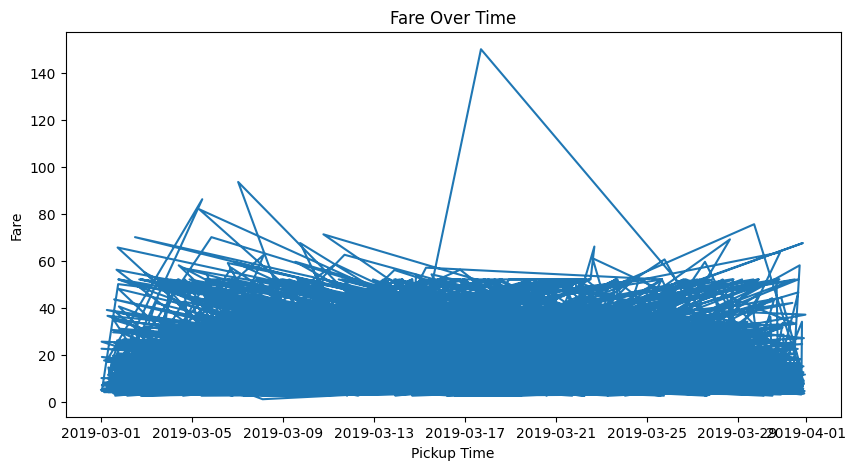

In [16]:
plt.figure(figsize=(10,5))

plt.plot(df['pickup'], df['fare'])

plt.title("Fare Over Time")
plt.xlabel("Pickup Time")
plt.ylabel("Fare")

plt.show()

**BAR CHART:**


Create a bar chart to show the total fare for each pickup_borough. Group the data
by pickup_borough and sum the fare for each group.

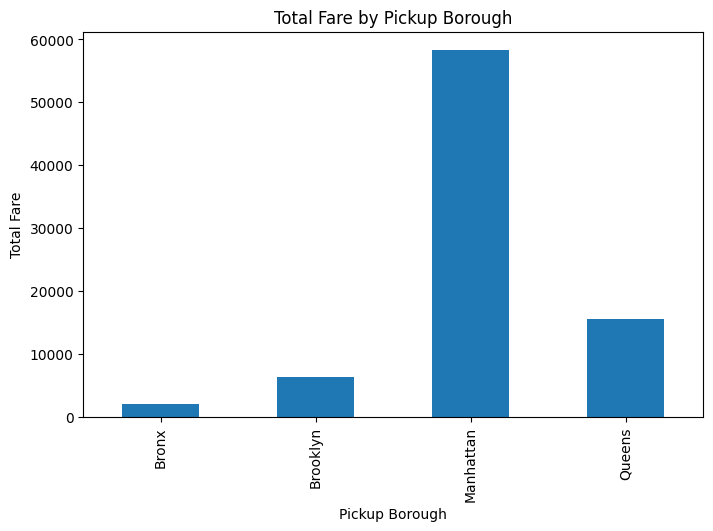

In [17]:
borough_fare = df.groupby('pickup_borough')['fare'].sum()

borough_fare.plot(kind='bar', figsize=(8,5))

plt.title("Total Fare by Pickup Borough")
plt.xlabel("Pickup Borough")
plt.ylabel("Total Fare")

plt.show()

**Pie Chart:**

Plot a pie chart showing the distribution of trips based on the payment method (credit
card, cash, etc.). Each slice should represent the count of trips for a specific payment
method.

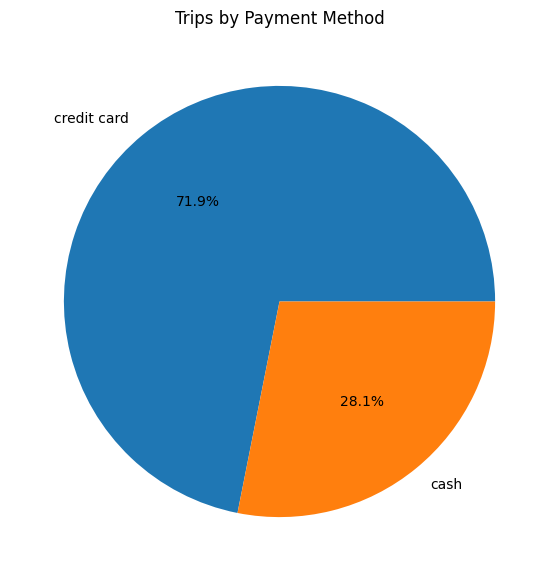

In [18]:
payment_counts = df['payment'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(payment_counts,
        labels=payment_counts.index,
        autopct='%1.1f%%')

plt.title("Trips by Payment Method")

plt.show()

**Histogram:**

Create a histogram to visualize the distribution of distance. Customize the number of
bins for better granularity and ensure the plot is easy to interpret.

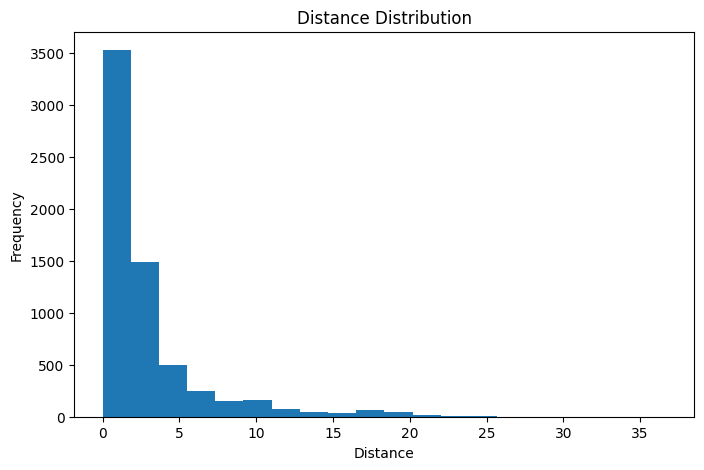

In [19]:
plt.figure(figsize=(8,5))

plt.hist(df['distance'], bins=20)

plt.title("Distance Distribution")
plt.xlabel("Distance")
plt.ylabel("Frequency")

plt.show()

**Box Plot:**

Plot a box plot to visualize the distribution of tip amounts for each pickup_borough.
Use pickup_borough as the categorical axis and tip as the numeric axis.

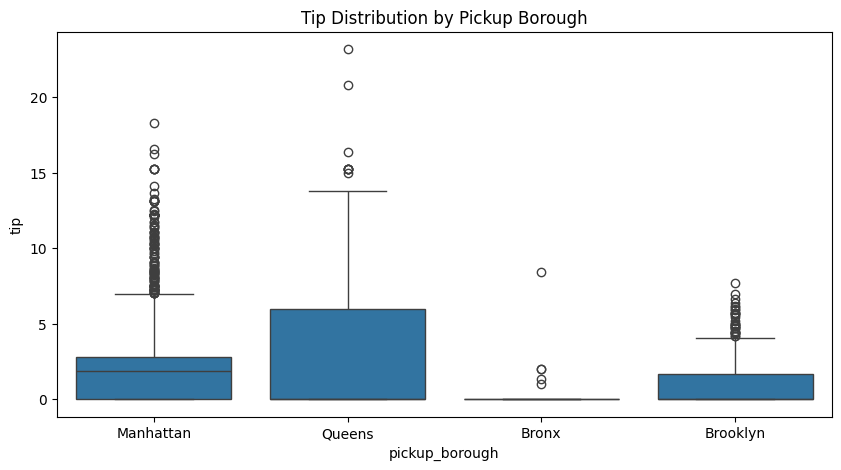

In [20]:
plt.figure(figsize=(10,5))

sns.boxplot(x='pickup_borough',
            y='tip',
            data=df)

plt.title("Tip Distribution by Pickup Borough")

plt.show()

**Visualizations using Seaborn:**

**Count Plot**


Create a count plot to visualize the number of trips in each pickup_borough. The
x-axis should represent the boroughs, and the y-axis should show the count of trips.

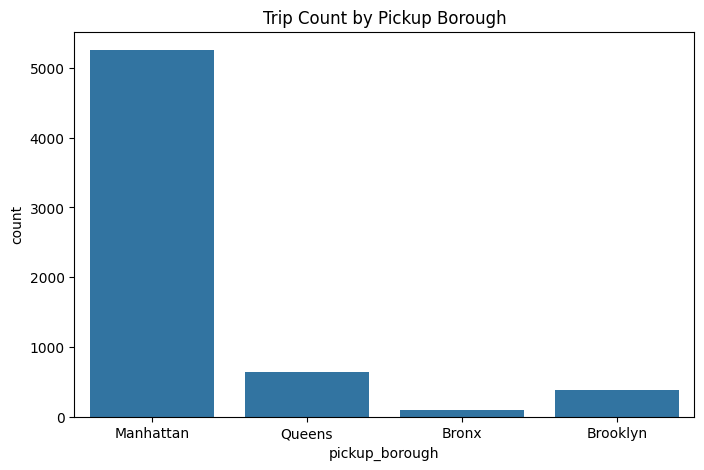

In [21]:
plt.figure(figsize=(8,5))

sns.countplot(x='pickup_borough', data=df)

plt.title("Trip Count by Pickup Borough")

plt.show()

**Scatter Plot**


Plot a scatter plot to show the relationship between distance and fare. Use
distance on the x-axis and fare on the y-axis to visualize any correlation. Color the
points based on the pickup_borough to differentiate the trips by their respective
boroughs.

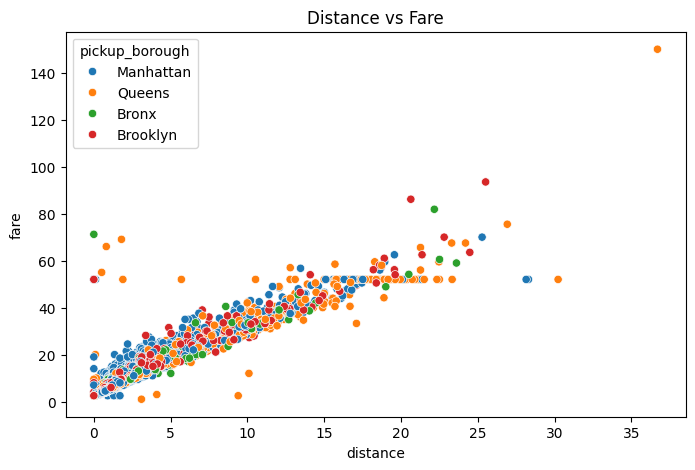

In [22]:
plt.figure(figsize=(8,5))

sns.scatterplot(x='distance',
                y='fare',
                hue='pickup_borough',
                data=df)

plt.title("Distance vs Fare")

plt.show()

**Heatmap**


Plot a heatmap to visualize the correlation between numerical variables such as
distance, fare, tip, tolls, and total. Use a correlation matrix to highlight the
relationships.

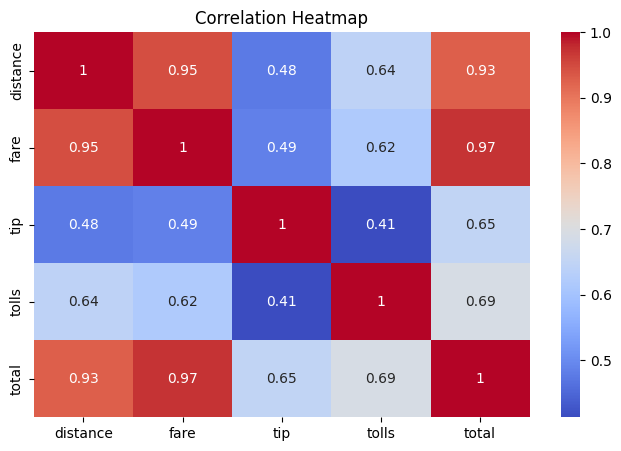

In [23]:
# Select numerical columns
corr = df[['distance', 'fare', 'tip', 'tolls', 'total']].corr()

plt.figure(figsize=(8,5))

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

**Pair Plot**

Create a pair plot to visualize the pairwise relationships between distance, fare, tip,
and total. Color the data points according to the pickup_zone method to compare
how different zones affect these variables.

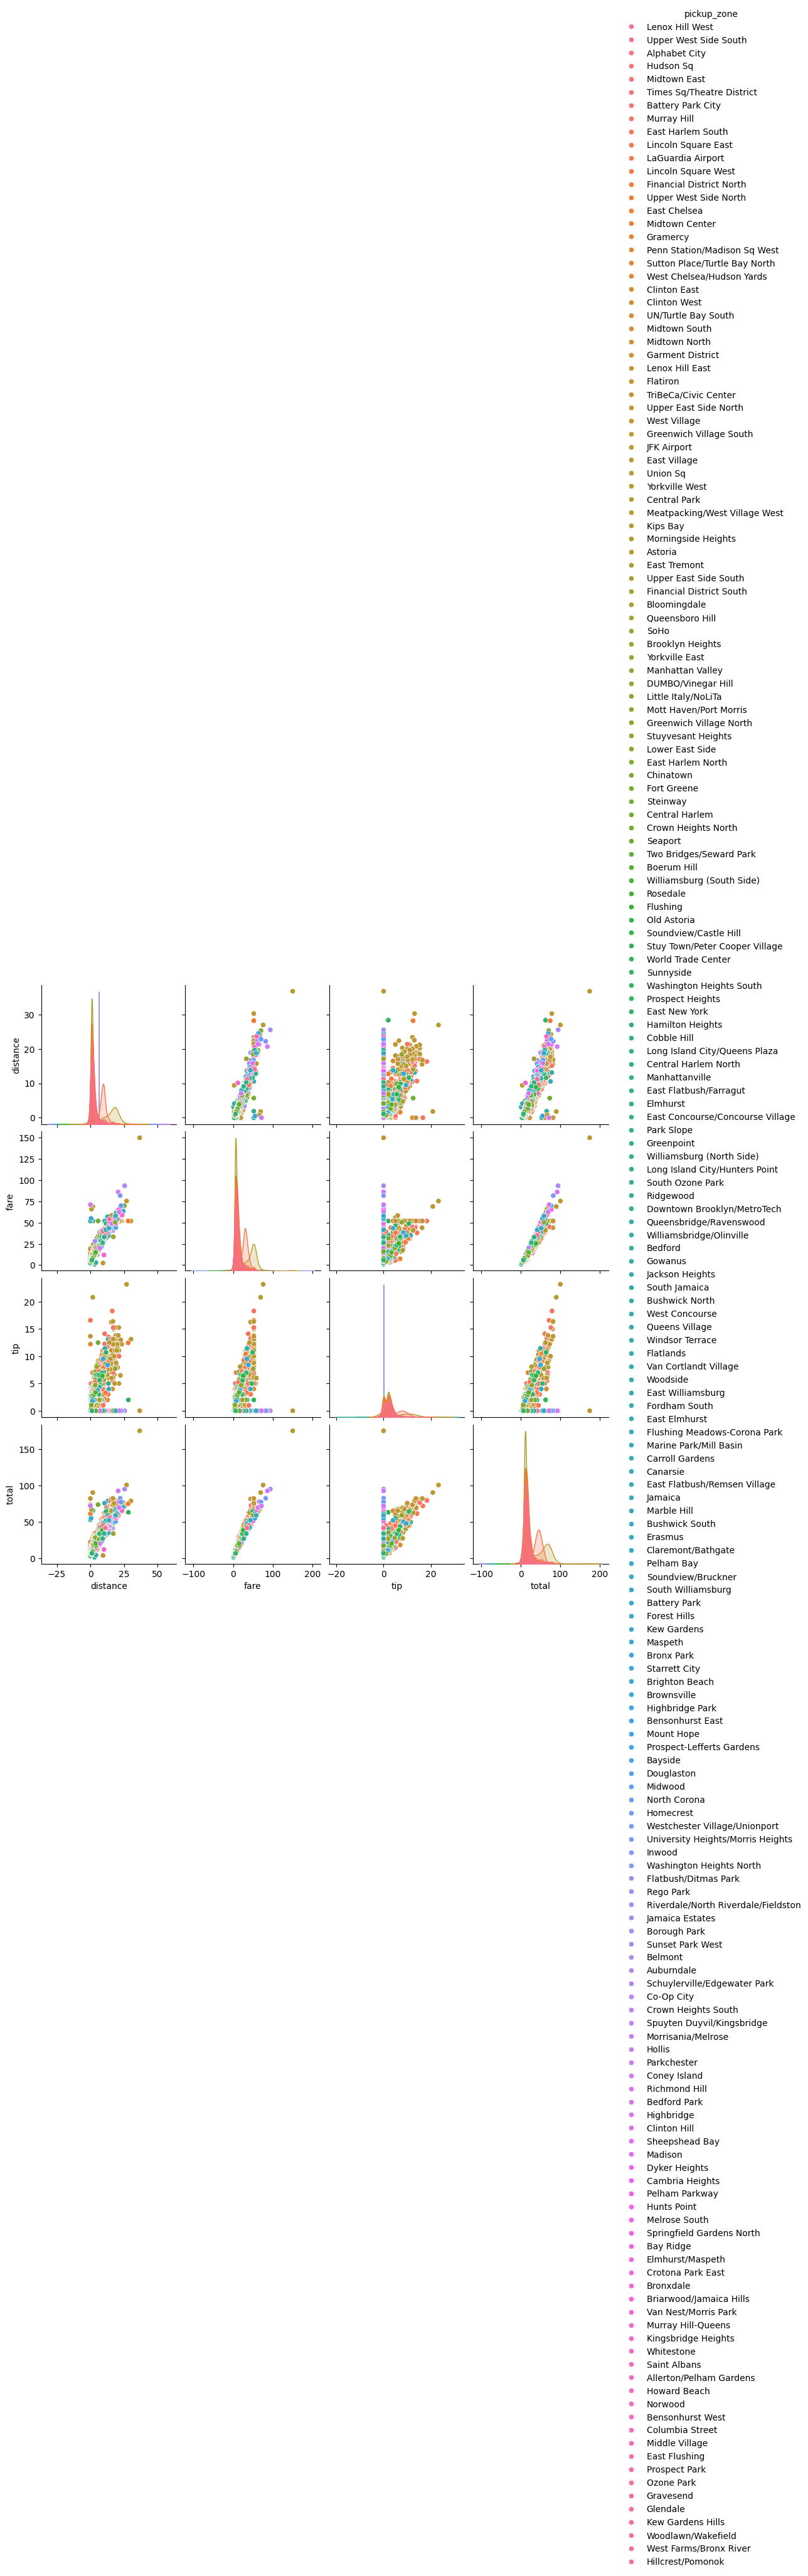

In [24]:
sns.pairplot(df[['distance',
                 'fare',
                 'tip',
                 'total',
                 'pickup_zone']],

             hue='pickup_zone')

plt.show()

**Violin Plot**


Plot a violin plot to show the distribution of fare for each payment method. Use the
payment method as the categorical axis and fare as the numeric axis to visualize its
distribution.

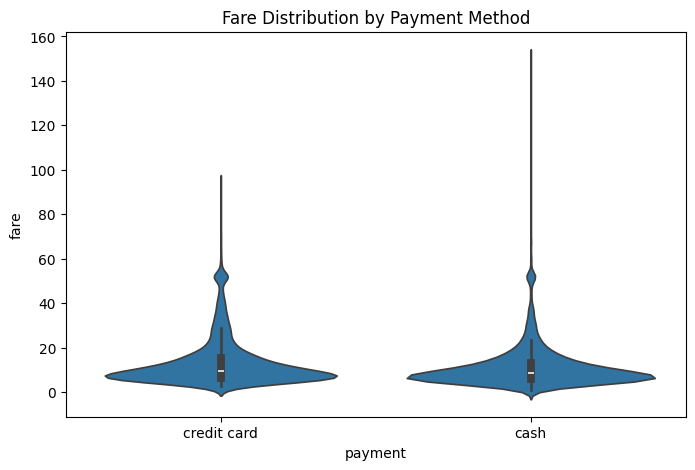

In [25]:
plt.figure(figsize=(8,5))

sns.violinplot(x='payment',
               y='fare',
               data=df)

plt.title("Fare Distribution by Payment Method")

plt.show()